# Exploratory Data Analysis (EDA) focalitzat en PolyPhen

## ClinVar Conflicting Variant Classification

In [2]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

df = pd.read_csv('../data/raw/clinvar_conflicting.csv',
                 dtype={'CHROM': str})


/var/folders/tl/5pdn6vld70l0ndj9lvltyvxw0000gn/T/ipykernel_30466/688925404.py:17: DtypeWarning: Columns (38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/clinvar_conflicting.csv',


In [3]:
# Vista general del conjunt de dades
print("Forma")
print(df.shape)

print("Tipus de dades")
df.info()

Forma
(65188, 46)
Tipus de dades
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65188 entries, 0 to 65187
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CHROM               65188 non-null  object 
 1   POS                 65188 non-null  int64  
 2   REF                 65188 non-null  object 
 3   ALT                 65188 non-null  object 
 4   AF_ESP              65188 non-null  float64
 5   AF_EXAC             65188 non-null  float64
 6   AF_TGP              65188 non-null  float64
 7   CLNDISDB            65188 non-null  object 
 8   CLNDISDBINCL        167 non-null    object 
 9   CLNDN               65188 non-null  object 
 10  CLNDNINCL           167 non-null    object 
 11  CLNHGVS             65188 non-null  object 
 12  CLNSIGINCL          167 non-null    object 
 13  CLNVC               65188 non-null  object 
 14  CLNVI               27659 non-null  object 
 15  MC                  

In [4]:
df.head(15)

,CHROM,POS,REF,ALT,AF_ESP,AF_EXAC,AF_TGP,CLNDISDB,CLNDISDBINCL,CLNDN,...,SIFT,PolyPhen,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,LoFtool,CADD_PHRED,CADD_RAW,BLOSUM62
0,1,1168180,G,C,0.0771,0.10020,0.1066,MedGen:CN169374,NaN,not_specified,...,tolerated,benign,NaN,NaN,NaN,NaN,NaN,1.053,-0.208682,2.0
1,1,1470752,G,A,0.0000,0.00000,0.0000,"MedGen:C1843891,OMIM:607454,Orphanet:ORPHA9877...",NaN,Spinocerebellar_ataxia_21|not_provided,...,deleterious_low_confidence,benign,NaN,NaN,NaN,NaN,NaN,31.000,6.517838,-3.0
2,1,1737942,A,G,0.0000,0.00001,0.0000,"Human_Phenotype_Ontology:HP:0000486,MedGen:C00...",NaN,Strabismus|Nystagmus|Hypothyroidism|Intellectu...,...,deleterious,probably_damaging,NaN,NaN,NaN,NaN,NaN,28.100,6.061752,-1.0
3,1,2160305,G,A,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.500,3.114491,NaN
4,1,2160305,G,T,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002",NaN,Shprintzen-Goldberg_syndrome,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.700,4.766224,-3.0
5,1,2160554,G,C,0.0000,0.00000,0.0000,"MedGen:C1321551,OMIM:182212,SNOMED_CT:83092002...",NaN,Shprintzen-Goldberg_syndrome|not_provided,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.700,4.079099,-2.0
6,1,3328358,T,C,0.0000,0.00000,0.0000,MedGen:CN169374,NaN,not_specified,...,NaN,NaN,NaN,NaN,NaN,NaN,0.101,0.172,-0.543433,-1.0
7,1,3328659,C,T,0.1523,0.13103,0.1060,MedGen:CN169374,NaN,not_specified,...,NaN,NaN,NaN,NaN,NaN,NaN,0.101,23.000,3.424422,-3.0
8,1,3347452,G,A,0.0000,0.00357,0.0030,"MedGen:C3809288,OMIM:615373|MedGen:CN169374|Me...",NaN,Left_ventricular_noncompaction_8|not_specified...,...,NaN,NaN,NaN,NaN,NaN,NaN,0.101,11.360,1.126629,1.0
9,1,5925304,G,A,0.0045,0.00231,0.0058,"MedGen:C0687120,Orphanet:ORPHA655,SNOMED_CT:20...",NaN,Nephronophthisis|not_specified,...,deleterious,benign,NaN,NaN,NaN,NaN,0.021,22.100,2.969650,-1.0


## Descripció de variables (resum)


| Variable (tipus) | Descripció | Variable (tipus) | Descripció | Variable (tipus) | Descripció |
|---|---|---|---|---|---|
| **CHROM** (cat) | Cromosoma | **POS** (num) | Posició dins cromosoma. | **REF** (cat) | Al·lel de referència. |
| **ALT** (cat) | Al·lel alternatiu. | **Allele** (cat) | Al·lel reportat. | **CLASS** (bin) | **Target**: 1 = conflictiva, 0 = consistent. |
| **AF_ESP** (num) | Freqüència al·lèlica (GO-ESP). | **AF_EXAC** (num) | Freqüència al·lèlica (ExAC). | **AF_TGP** (num) | Freqüència al·lèlica (1000G). |
| **CLNDISDB** (txt/cat↑) | IDs de malalties (tag-value). | **CLNDISDBINCL** (txt) | Idem “included variant”. | **CLNDN** (txt/cat) | Nom preferit de malaltia. |
| **CLNDNINCL** (txt) | Idem “included variant”. | **CLNHGVS** (txt) | Expressió HGVS. | **CLNSIGINCL** (txt) | Significància clínica “included variant”. |
| **CLNVC** (cat) | Tipus de variant (SNV, deletion, insertion...). | **CLNVI** (txt/cat) | Info extra / refs de variant. | **MC** (txt/cat) | Conseqüència molecular |
| **ORIGIN** (int/cat) | Origen al·lel. | **SSR** (num) | Regió/repetició. | **DISTANCE** (num) | Distància a feature. |
| **Consequence** (cat) | Conseqüències VEP. | **IMPACT** (cat) | Impacte funcional (HIGH/MODERATE/LOW/MODIFIER). | **SYMBOL** (cat) | Gen. |
| **Feature_type** (cat) | Tipus de feature. | **Feature** (cat) | Identificador de feature. | **BIOTYPE** (cat) | Biotip. |
| **EXON** (txt) | Exó en format `x/y`. | **INTRON** (txt) | Intró en format `x/y`. | **cDNA_position** (txt) | Posició relativa a cDNA. |
| **CDS_position** (txt) | Posició relativa a CDS. | **Protein_position** (txt) | Posició relativa a proteïna. | **Amino_acids** (txt) | Canvi AA. |
| **Codons** (txt) | Canvi de codó. | **STRAND** (cat) | Cadena (+1 / -1). | **BAM_EDIT** (cat) | Estat/flag de camp categòric. |
| **SIFT** (cat) | Predicció SIFT. | **PolyPhen** (cat) | Predicció PolyPhen. | **MOTIF_NAME** (txt) | Nom del motiu. |
| **MOTIF_POS** (num) | Posició en motiu. | **HIGH_INF_POS** (txt) | Flag/posició. | **MOTIF_SCORE_CHANGE** (num) | Canvi score del motiu . |
| **LoFtool** (num) | Tolerància a LoF (loss-of-function). | **CADD_PHRED** (num) | Score CADD. | **CADD_RAW** (num) | Score CADD. |
| **BLOSUM62** (num) | Score BLOSUM62 del canvi AA. |  |  |  |  |

## Distribució de la variable obkectiu PolyPhen

Tot i que PolyPhen té un 61.96% de valors nuls, encara disposa de 24,796 mostres no nul·les, suficients per analitzar aquesta variable.
Entre les variants amb valor disponible, la categoria **benign** és la més freqüent (53.8%), seguida de **probably_damaging** (30.4%) i **possibly_damaging** (15.9%). Això indica que la majoria de variants amb anotació PolyPhen són predites com a benignes, tot i que una proporció considerable es classifica com potencialment danyosa.

Mostres totals: 65,188
Mostres no nules a PolyPhen: 24,796
Percentatge de nuls a PolyPhen: 61.96%


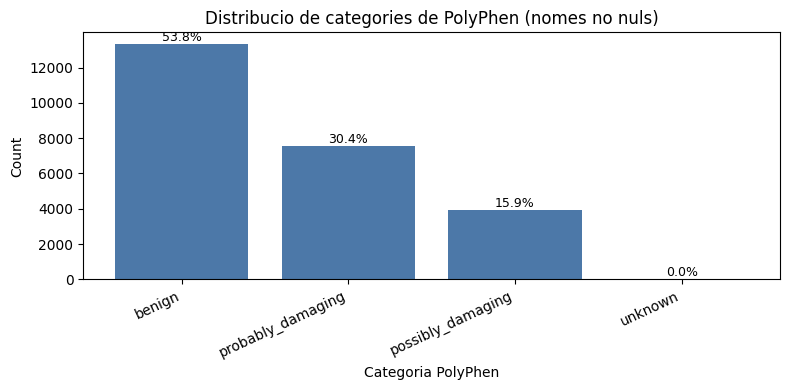

In [5]:
# Resum de cobertura de PolyPhen + distribucio de categories
poly_col = "PolyPhen"
assert poly_col in df.columns, "No existeix la columna PolyPhen al dataset"

poly_non_null = df[poly_col].notna().sum()
poly_missing_pct = df[poly_col].isna().mean() * 100
print(f"Mostres totals: {len(df):,}")
print(f"Mostres no nules a PolyPhen: {poly_non_null:,}")
print(f"Percentatge de nuls a PolyPhen: {poly_missing_pct:.2f}%")

poly_df = df.loc[df[poly_col].notna(), [poly_col, "CLASS"]].copy()
poly_counts = poly_df[poly_col].value_counts()
poly_pct = poly_df[poly_col].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 4))
plt.bar(poly_counts.index.astype(str), poly_counts.values, color="#4C78A8")
plt.title("Distribucio de categories de PolyPhen (nomes no nuls)")
plt.xlabel("Categoria PolyPhen")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
for i, cat in enumerate(poly_counts.index):
    plt.text(i, poly_counts.loc[cat], f"{poly_pct.loc[cat]:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


### Taxa de conflicte segons categoria de PolyPhen

Aquest gràfic mostra la proporció de variants amb classificació conflictiva (CLASS = 1) per a cada categoria de **PolyPhen** (barres blaves), juntament amb el nombre total de mostres disponibles per categoria (línia vermella discontínua).

S’observa que les categories **benign**, **possibly_damaging** i **probably_damaging** presenten taxes de conflicte relativament similars (al voltant de 0.25–0.30), mentre que la categoria **unknown** mostra una proporció de conflicte molt baixa. Tanmateix, aquesta última categoria té un nombre molt reduït de mostres, fet que limita la fiabilitat de la seva interpretació.

Pel que fa al volum de dades, la categoria **benign** és la més freqüent, seguida de **probably_damaging** i **possibly_damaging**, mentre que **unknown** és residual. En general, les tres categories principals tenen una mida de mostra suficient per considerar que les seves estimacions de taxa de conflicte són relativament estables.

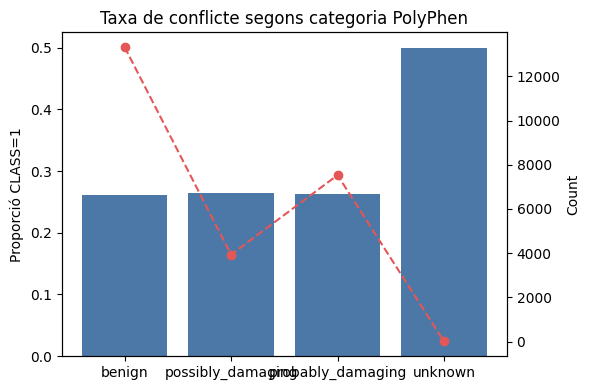

In [6]:
rate = poly_df.groupby("PolyPhen")["CLASS"].mean()
counts = poly_df["PolyPhen"].value_counts().reindex(rate.index)

fig, ax = plt.subplots(figsize=(6,4))

ax.bar(rate.index.astype(str), rate.values, color="#4C78A8")
ax.set_ylabel("Proporció CLASS=1")
ax.set_title("Taxa de conflicte segons categoria PolyPhen")

ax2 = ax.twinx()
ax2.plot(range(len(counts)), counts.values, marker="o", linestyle="--", color="#E45756")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Distribució de la posició genòmica segons la categoria de PolyPhen

Aquest boxplot mostra la distribució de la **posició genòmica (POS)** de les variants per a cada categoria de **PolyPhen**. Les tres categories principals —*benign*, *probably_damaging* i *possibly_damaging*— presenten distribucions molt similars, amb medians i rangs interquartílics comparables i presència d’outliers en posicions genòmiques elevades. En general, el gràfic suggereix que la **posició genòmica per si sola no separa clarament les categories de PolyPhen**.

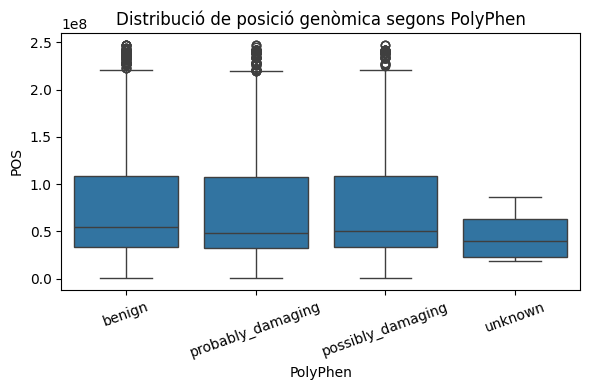

In [8]:
# Boxplot de POS per categories de PolyPhen
plot_df = df.loc[df["PolyPhen"].notna(), ["PolyPhen", "POS"]].copy()
plot_df["POS"] = pd.to_numeric(plot_df["POS"], errors="coerce")
plot_df = plot_df.dropna(subset=["POS"])

plt.figure(figsize=(6,4))
sns.boxplot(x="PolyPhen", y="POS", data=plot_df)

plt.title("Distribució de posició genòmica segons PolyPhen")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Distribució de les categories de PolyPhen segons el nucleòtid de referència

Aquest gràfic mostra la distribució de les categories de **PolyPhen** en funció del **nucleòtid de referència (REF)** de la variant. S’observa que la majoria de variants es concentren en nucleòtids simples com **C, G, A i T**, mentre que altres categories de REF tenen una presència molt reduïda.

En tots els nucleòtids principals, la categoria **benign** és la més freqüent, seguida de **probably_damaging** i **possibly_damaging**, mantenint una proporció similar entre nucleòtids. Això suggereix que el tipus de nucleòtid de referència, per si sol, **no sembla determinar clarament la categoria de PolyPhen**, tot i que pot contribuir parcialment en combinació amb altres característiques de la variant.

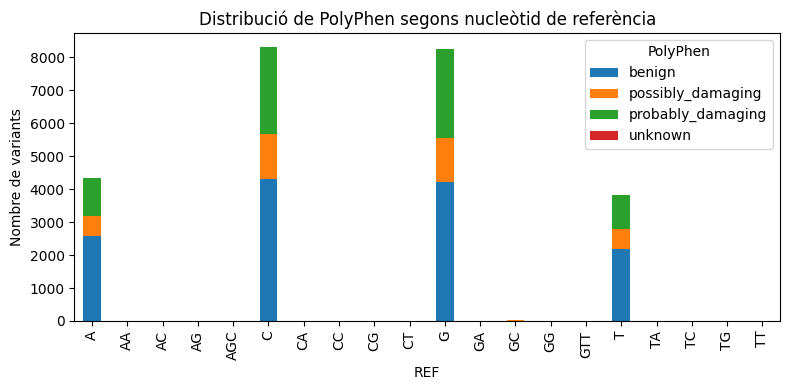

In [10]:
variant_poly = df.groupby(["REF","PolyPhen"]).size().unstack()

variant_poly.plot(kind="bar", stacked=True, figsize=(8,4))

plt.title("Distribució de PolyPhen segons nucleòtid de referència")
plt.ylabel("Nombre de variants")

plt.tight_layout()
plt.show()

### Distribució de les categories de PolyPhen per cromosoma

Aquest gràfic mostra el nombre de variants per cromosoma, separades segons la categoria de **PolyPhen**. S’observa que alguns cromosomes, com el **2, 5, 11 i 17**, concentren un nombre especialment elevat de variants, mentre que altres cromosomes presenten menys observacions.

Pel que fa a la composició de categories, la distribució és relativament similar entre cromosomes: la categoria **benign** és generalment la més freqüent, seguida de **probably_damaging** i **possibly_damaging**, mentre que **unknown** té una presència molt reduïda. En conjunt, el gràfic suggereix que les categories de PolyPhen apareixen distribuïdes al llarg de diversos cromosomes sense una concentració clara d’una categoria específica en un cromosoma concret.

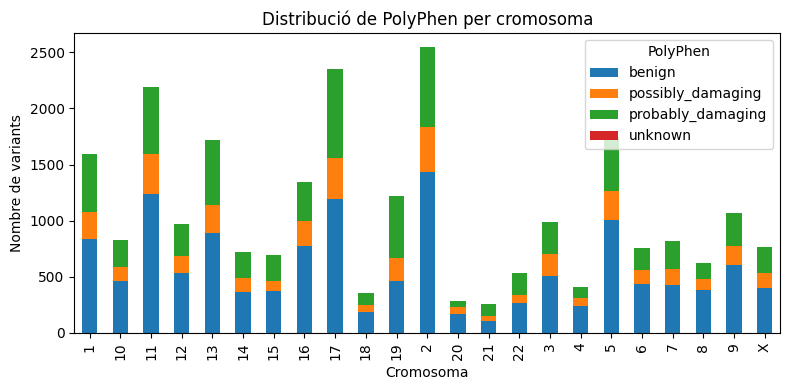

In [12]:
chrom_poly = df.groupby(["CHROM","PolyPhen"]).size().unstack()

chrom_poly.plot(kind="bar", stacked=True, figsize=(8,4))

plt.title("Distribució de PolyPhen per cromosoma")
plt.ylabel("Nombre de variants")
plt.xlabel("Cromosoma")

plt.tight_layout()
plt.show()

## Definició de la variable objectiu i partició de dades


In [18]:
poly_map = {
    "benign": 0,
    "possibly_damaging": 1,
    "probably_damaging": 2
}

df_poly = df[df["PolyPhen"].isin(poly_map.keys())].copy()
df_poly["PolyPhen_target"] = df_poly["PolyPhen"].map(poly_map)

X = df_poly.drop(columns=["PolyPhen", "PolyPhen_target"])
y = df_poly["PolyPhen_target"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

## Processat de dades

In [19]:
cols_high_missing = [
    'MOTIF_SCORE_CHANGE',
    'HIGH_INF_POS',
    'MOTIF_POS',
    'MOTIF_NAME',
    'DISTANCE',
    'SSR',
    'CLNSIGINCL',
    'CLNDISDBINCL',
    'CLNDNINCL'
]

# Eliminem les columnes amb molt missing
X_train_val = X_train_val.drop(columns=cols_high_missing, errors="ignore")
X_test = X_test.drop(columns=cols_high_missing, errors="ignore")

# Columnes numèriques i categòriques
num_cols = X_train_val.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_val.select_dtypes(exclude=np.number).columns.tolist()

# Preprocessat numèric
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Preprocessat categòric
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

# Preprocessador global
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

## Decision Tree

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['INTRON']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['INTRON']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['INTRON']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['INTRON']. At least one non-missing value is needed for imputation 

Millors paràmetres: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
Millor CV F1 macro: 0.6186705463540786

Classification report al test:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1333
           1       0.26      0.42      0.32       393
           2       0.70      0.76      0.73       754

    accuracy                           0.67      2480
   macro avg       0.62      0.63      0.61      2480
weighted avg       0.74      0.67      0.70      2480

F1 macro al test: 0.6122439706064714


/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['INTRON']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


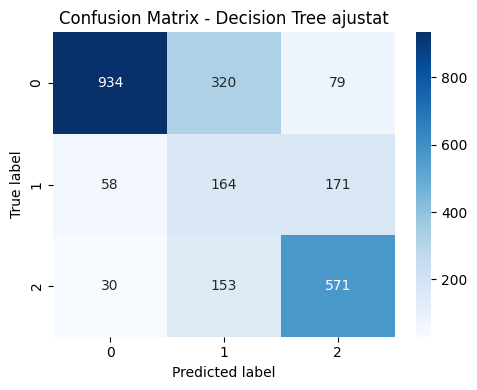

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Model
dt = DecisionTreeClassifier(
    random_state=42
)

# Pipeline
pipeline_dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", dt)
])

# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Graella d'hiperparàmetres
param_grid = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}

# Grid Search
grid_dt = GridSearchCV(
    pipeline_dt,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

# Entrenament
grid_dt.fit(X_train_val, y_train_val)

print("Millors paràmetres:", grid_dt.best_params_)
print("Millor CV F1 macro:", grid_dt.best_score_)

# Millor model
best_dt = grid_dt.best_estimator_

# Prediccions a test
y_pred = best_dt.predict(X_test)

# Resultats de test
print("\nClassification report al test:")
print(classification_report(y_test, y_pred))

test_f1_macro = f1_score(y_test, y_pred, average="macro")
print("F1 macro al test:", test_f1_macro)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Decision Tree ajustat")
plt.tight_layout()
plt.show()